# **EDA Notebook**



---
## 0. Setup Environment

In [2]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [3]:
group_name = "Group 11"
student_name = "Rose Marie Tazbaz"
student_id = "25742507"

In [4]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [7]:
# <Student to fill this section>

### 0.b Import Packages

In [8]:
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## B. Data Understanding

In [9]:
# Do not modify this code
try:
  df = pd.read_csv(at.folder_path / "store.csv")
except Exception as e:
  print(e)

### B.1 Explore Dataset

In [10]:
print("shape:", df.shape)
df.head()

shape: (701, 3)


,store_id,sales_person_id,name
0,e88ca038-7d3c-4343-a8cf-a273d7162426,28141e19-49e8-4090-9196-6e8f43b10de8,Next-Door Bike Store
1,48cab4d0-b342-451e-8f51-c0deeba6cbc4,16eb6889-25f7-475a-9eff-92024a00fde9,Professional Sales and Service
2,8b7b3e1a-51b7-4f62-9633-190ad3fa4471,0ca60d7b-b278-4a10-88c7-aa2c62611482,Riders Company
3,f1de0f2a-8c21-49eb-9631-01fd08c7e49b,0e8f1395-12c4-4d5b-b2df-257bc78a9b29,The Bike Mechanics
4,562eb541-ed31-4a78-b58f-ec1ecf57dea7,9787b7d5-2461-464d-9354-2da1defdb675,Nationwide Supply


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   store_id         701 non-null    object
 1   sales_person_id  701 non-null    object
 2   name             701 non-null    object
dtypes: object(3)
memory usage: 16.6+ KB


In [12]:
df.describe(include='all')

,store_id,sales_person_id,name
count,701,701,701
unique,701,13,699
top,fb3f2681-31a3-4309-8654-088e5075dca7,28141e19-49e8-4090-9196-6e8f43b10de8,Sports Products Store
freq,1,80,2


In [13]:
df.isnull().sum()

,0
store_id,0
sales_person_id,0
name,0


In [14]:
dataset_insights = "The store dataset comprises 701 observations and 3 variables that correspond to retail store details, such as store IDs, allocated salespeople, and names of the stores. There are no missing values, which means that the dataset is well-formed and ready for further processing. The store dataset seems to serve mainly as a lookup table that could later be connected with transaction datasets to assess the behaviour of sales in various stores and their corresponding salespeople. Despite the fact that there are no transaction variables in the dataset, it might still prove useful for anomaly detection tasks by helping to identify abnormal sales orders in particular stores and salespeople."

In [15]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.2 Explore Feature of Interest `sales_person_id`

In [16]:
print("Unique sales persons:", df['sales_person_id'].nunique())

sales_person_counts = df['sales_person_id'].value_counts()
sales_person_counts.describe()

Unique sales persons: 13


,count
count,13.000000
mean,53.923077
std,19.215712
min,38.000000
25%,40.000000
50%,40.000000
75%,76.000000
max,80.000000


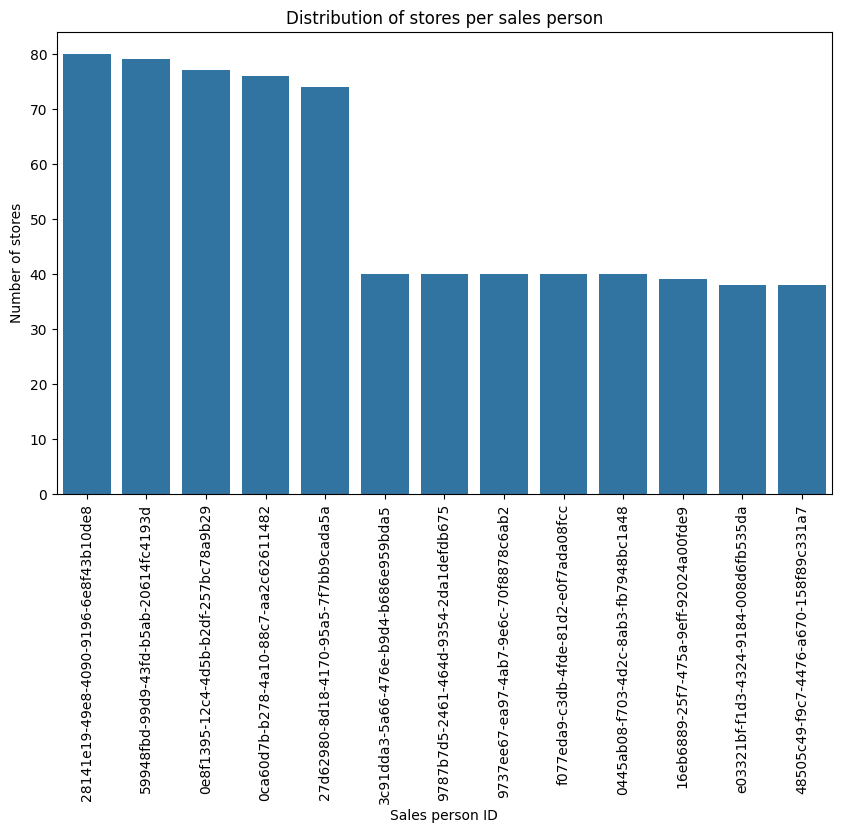

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=sales_person_counts.index,
    y=sales_person_counts.values
)

plt.xticks(rotation=90)

plt.title('Distribution of stores per sales person')
plt.xlabel('Sales person ID')
plt.ylabel('Number of stores')

plt.show()

In [18]:
sales_person_percentage = (
    sales_person_counts / sales_person_counts.sum()
) * 100

sales_person_percentage

,count
sales_person_id,
28141e19-49e8-4090-9196-6e8f43b10de8,11.412268
59948fbd-99d9-43fd-b5ab-20614fc4193d,11.269615
0e8f1395-12c4-4d5b-b2df-257bc78a9b29,10.984308
0ca60d7b-b278-4a10-88c7-aa2c62611482,10.841655
27d62980-8d18-4170-95a5-7f7bb9cada5a,10.556348
3c91dda3-5a66-476e-b9d4-b686e959bda5,5.706134
9787b7d5-2461-464d-9354-2da1defdb675,5.706134
9737ee67-ea97-4ab7-9e6c-70f8878c6ab2,5.706134
f077eda9-c3db-4fde-81d2-e0f7ada08fcc,5.706134


In [19]:
feature_1_insights = "The sales_person_id feature contains 13 unique sales representatives assigned across 701 stores, indicating that each sales person is responsible for managing multiple retail locations. The average number of stores managed per sales representative is approximately 54, although the distribution is uneven across individuals. The feature distribution reveals moderate variability, with some sales representatives managing over 11% of all stores, while others manage close to 5%. This imbalance suggests that sales activity may be concentrated around certain representatives, potentially leading to operational differences and unequal transaction volumes across the business. From an anomaly detection perspective, this imbalance is important because sales representatives responsible for larger numbers of stores may naturally generate higher transaction variability and a greater number of unusual sales orders. As a result, anomalies identified in later modelling stages should be interpreted carefully to distinguish between genuinely suspicious behaviour and patterns driven by higher transaction exposure. No missing values were identified within this feature, indicating complete assignment of stores to sales personnel. However, the relatively low cardinality of the variable may limit its standalone predictive value within anomaly detection models. Instead, the feature is expected to provide contextual business information when combined with transactional datasets."

In [20]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### B.3 Explore Feature of Interest `name`

In [21]:
# Number of unique store names
print("Unique store names:", df['name'].nunique())

# Total number of records
print("Total records:", len(df))

Unique store names: 699
Total records: 701


In [22]:
duplicate_store_names = df['name'].value_counts()
duplicate_store_names[duplicate_store_names > 1]

,count
name,
Sports Products Store,2
Friendly Bike Shop,2


In [23]:
unique_percentage = (
    df['name'].nunique() / len(df)
) * 100

print(f"Percentage of unique store names: {unique_percentage:.2f}%")

Percentage of unique store names: 99.71%


In [24]:
feature_2_insights = "The name feature contains 699 unique store names across 701 records, resulting in a uniqueness ratio of 99.71%. This indicates that almost all stores within the dataset are individually identifiable through their names, suggesting a high level of data uniqueness and overall consistency. Only two duplicated store names were identified: Sports Products Store and Friendly Bike Shop, each appearing twice in the dataset. These duplicates may represent legitimate franchise structures, shared branding, or naming conventions used across multiple locations. However, duplicated business names may also introduce ambiguity during transactional analysis and anomaly investigation if stores are not properly differentiated using unique identifiers. From a business and anomaly detection perspective, repeated store names could complicate the identification of suspicious transactions, duplicate records, or potentially fraudulent behaviour when analysing sales activity at the store level. This highlights the importance of relying on the store_id feature as the primary unique identifier during data integration and modelling processes. Although the name feature is unlikely to provide strong predictive value within anomaly detection models due to its highly unique categorical structure, it may still support the interpretation of anomalous sales patterns by helping identify whether unusual transactions are concentrated within particular retail locations or business groups. One limitation of this feature is that textual store names may introduce inconsistencies related to formatting, spelling, abbreviations, or duplicated naming conventions. As a result, the feature is expected to serve mainly as contextual business information rather than as a core modelling variable."

In [25]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.4 Explore Feature of Interest `store_id`

In [26]:
# Number of unique store IDs
print("Unique store IDs:", df['store_id'].nunique())

# Check duplicated IDs
duplicated_ids = df['store_id'].duplicated().sum()

print("Duplicated store IDs:", duplicated_ids)

Unique store IDs: 701
Duplicated store IDs: 0


In [27]:
feature_n_insights = "In terms of uniqueness, the store_id attribute has 701 unique identifiers spread across 701 records. In other words, the ratio of uniqueness here is 100% with no duplication found in the variable. As such, this suggests a high level of entity integrity on this feature, and one can assume that there are no duplicates or issues with unique identification of stores. Indeed, in terms of data quality management, the absence of duplicates or missing identifiers is very crucial for reliable and consistent work with the data. As far as the current case study is concerned, the store_id variable will most likely become extremely important in merging the store info with the transactions that will be used in anomaly detection modelling. Unique identifiers allow us to make sure that our unusual sales orders are really made at certain shops and not somewhere else. It is noteworthy that while store_id is an extremely important technical aspect in terms of traceability and data interpretation, it does not carry any behaviour-related data and, therefore, will not be useful in predictive models."

In [28]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)